# SpliceAI on ClinVar: splice-effect predictions

Loads the full SpliceAI results (`clinvar_spliceai_scores_rbp.tsv`, built by `../12_variant_effect_prediction/splicing/`) -- 4,474,009 variants attempted, 4,137,146 scored (92.5%; the rest came back unscored, likely too close to chromosome ends or in unannotated regions -- a SpliceAI/annotation limitation, not a pipeline problem).

**Data file is not checked into git** -- regenerate via `12_variant_effect_prediction/splicing/merge_spliceai_results.py`, or pull `clinvar_spliceai_scores_rbp.tsv` from `/u/project/kappel/ddcohn/protein_variant_effects/` on Hoffman2.

**RBP-only version.** Filtered to the 2,215-gene RNA-binding-protein list in `../12_variant_effect_prediction/rbp_filter/rbp_gene_symbols.txt` (union of a classic-RNA-binding-domain list and RBP2GO's high-confidence human RBP dataset -- see that folder's README for the full method). The genome-wide version of this notebook is `spliceai_clinvar_exploration.ipynb`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
PALETTE = ["#8ecae6", "#219ebc", "#023047", "#ffb703", "#fb8500"]
sns.set_palette(PALETTE)

SCORE_COLS = ["DS_AG", "DS_AL", "DS_DG", "DS_DL"]
LABELS = ["Acceptor Gain", "Acceptor Loss", "Donor Gain", "Donor Loss"]

## Load data

In [2]:
df = pd.read_csv("clinvar_spliceai_scores_rbp.tsv", sep="\t")
print(f"{len(df):,} scored variants")
df.head()

388,515 scored variants


,VariationID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
0,40,0.00,0.06,0.00,0.00,-25,-30,-12,-1
1,41,0.01,0.01,0.00,0.00,3,-25,-25,32
2,42,0.03,0.00,0.02,0.00,-48,28,28,-48
3,43,0.00,0.00,0.00,0.00,12,-36,-20,14
4,44,0.00,0.00,0.00,0.01,-12,-3,-12,-5


## Delta score distributions

Each of the four scores ranges 0-1. SpliceAI's own published guidance: >=0.2 suggests a possible splicing effect, >=0.5 is high-confidence. Most variants should score ~0 across all four (no predicted splicing consequence).

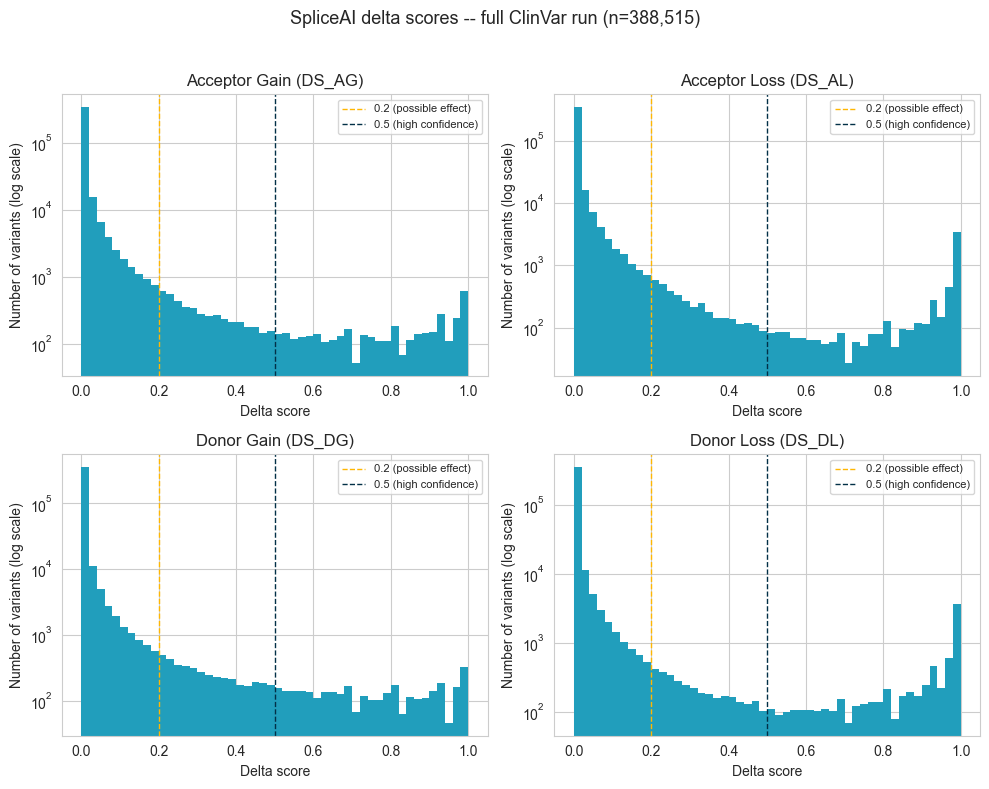

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col, label in zip(axes.flat, SCORE_COLS, LABELS):
    ax.hist(df[col], bins=50, color="#219ebc", edgecolor="none")
    ax.set_yscale("log")
    ax.set_title(f"{label} ({col})")
    ax.set_xlabel("Delta score")
    ax.set_ylabel("Number of variants (log scale)")
    ax.axvline(0.2, color="#ffb703", linestyle="--", linewidth=1, label="0.2 (possible effect)")
    ax.axvline(0.5, color="#023047", linestyle="--", linewidth=1, label="0.5 (high confidence)")
    ax.legend(fontsize=8)
fig.suptitle(f"SpliceAI delta scores -- full ClinVar run (n={len(df):,})", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Summary counts

In [4]:
max_score = df[SCORE_COLS].max(axis=1)
print(f"Total scored variants: {len(df):,}")
print(f"Max delta score >= 0.2 (possible splicing effect): {(max_score >= 0.2).sum():,} "
      f"({(max_score >= 0.2).mean()*100:.2f}%)")
print(f"Max delta score >= 0.5 (high-confidence effect): {(max_score >= 0.5).sum():,} "
      f"({(max_score >= 0.5).mean()*100:.2f}%)")

Total scored variants: 388,515
Max delta score >= 0.2 (possible splicing effect): 27,847 (7.17%)
Max delta score >= 0.5 (high-confidence effect): 16,302 (4.20%)


## Variants with the strongest predicted splicing effect

In [5]:
top_variants = df.loc[max_score.sort_values(ascending=False).index[:25]]
top_variants[["VariationID"] + SCORE_COLS + ["DP_AG", "DP_AL", "DP_DG", "DP_DL"]].head(25)

,VariationID,DS_AG,DS_AL,DS_DG,DS_DL,DP_AG,DP_AL,DP_DG,DP_DL
270193,3666892,1.00,1.0,0.00,0.00,0,1,17,-37
326422,4293561,0.99,1.0,0.00,0.00,0,2,-50,0
326532,4298008,0.97,1.0,0.00,0.00,2,1,2,38
183867,2628341,0.82,1.0,0.00,0.00,-20,-1,41,0
326501,4294477,0.00,0.0,0.09,1.00,-9,47,-12,13
345822,4468413,0.61,1.0,0.00,0.44,-5,-1,-15,-39
345823,4468414,0.97,1.0,0.00,0.42,-2,-1,-2,-39
183956,2630834,0.99,1.0,0.00,0.00,-2,-1,-22,0
326490,4294364,0.68,1.0,0.00,0.02,13,2,-30,12
326469,4294060,0.00,0.0,0.99,1.00,0,-1,47,-1


## Cross-reference with ClinicalSignificance

Do pathogenic variants actually score higher for predicted splicing disruption than benign ones? This is the strongest validation available for this dataset -- if the pattern holds, it's real evidence the predictions carry biological signal, not just noise.

In [6]:
meta = pd.read_csv("clinvar_metadata_lookup_rbp.tsv", sep="\t")
df2 = df.merge(meta, on="VariationID", how="left")

def simplify_sig(s):
    if not isinstance(s, str):
        return "Other/Unknown"
    s = s.lower()
    if "conflicting" in s:
        return "Conflicting"
    if "pathogenic" in s and "benign" not in s:
        return "Pathogenic/Likely pathogenic"
    if "benign" in s and "pathogenic" not in s:
        return "Benign/Likely benign"
    if "uncertain" in s:
        return "Uncertain significance"
    return "Other/Unknown"

df2["sig_group"] = df2["ClinicalSignificance"].apply(simplify_sig)
df2["max_score"] = df2[SCORE_COLS].max(axis=1)
print(df2["sig_group"].value_counts())

sig_group
Uncertain significance          208678
Benign/Likely benign            115094
Other/Unknown                    29678
Pathogenic/Likely pathogenic     22378
Conflicting                      12744
Name: count, dtype: int64


/var/folders/pf/8s82tkcj2z92hkmhf8vknhh80000gn/T/ipykernel_1255/766796256.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df2, x="sig_group", y="max_score", order=order, ax=ax, showfliers=False, palette=PALETTE)


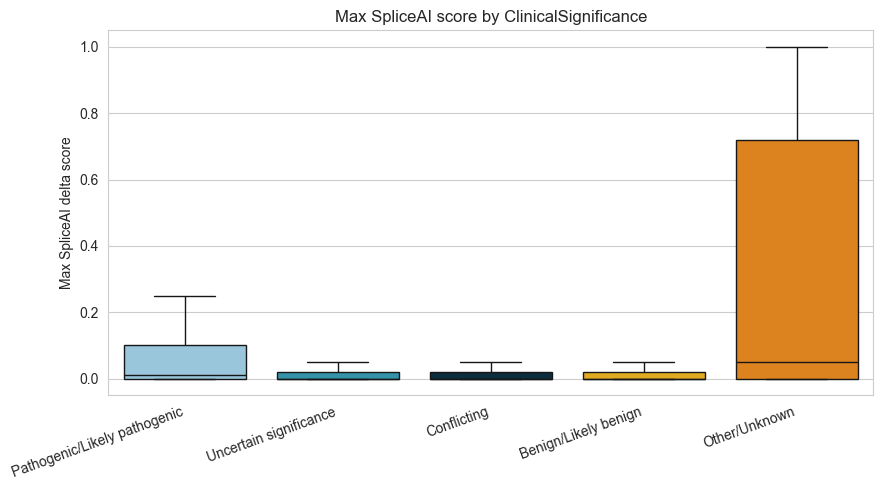

                                  mean  median   count
sig_group                                             
Pathogenic/Likely pathogenic  0.180776    0.01   22378
Uncertain significance        0.035759    0.00  208678
Conflicting                   0.042976    0.00   12744
Benign/Likely benign          0.022621    0.00  115094
Other/Unknown                 0.309725    0.05   29678

% with max score >= 0.2 (possible splicing effect), by group:
sig_group
Pathogenic/Likely pathogenic    20.296720
Uncertain significance           4.368932
Conflicting                      5.257376
Benign/Likely benign             1.946235
Other/Unknown                   38.021430
dtype: float64


/var/folders/pf/8s82tkcj2z92hkmhf8vknhh80000gn/T/ipykernel_1255/766796256.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  rate = df2.groupby("sig_group").apply(lambda g: (g["max_score"] >= 0.2).mean() * 100)


In [7]:
order = ["Pathogenic/Likely pathogenic", "Uncertain significance", "Conflicting", "Benign/Likely benign", "Other/Unknown"]
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df2, x="sig_group", y="max_score", order=order, ax=ax, showfliers=False, palette=PALETTE)
ax.set_xlabel("")
ax.set_ylabel("Max SpliceAI delta score")
ax.set_title("Max SpliceAI score by ClinicalSignificance")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(df2.groupby("sig_group")["max_score"].agg(["mean", "median", "count"]).loc[order])
print()
rate = df2.groupby("sig_group").apply(lambda g: (g["max_score"] >= 0.2).mean() * 100)
print("% with max score >= 0.2 (possible splicing effect), by group:")
print(rate.loc[order])

**Note on "Other/Unknown":** this bucket scores *higher* than even confirmed Pathogenic variants, which is surprising at first glance. Checking the raw `ClinicalSignificance` values shows it's almost entirely ClinVar entries with **no clinical classification at all** (`-` or "not provided"), not some exotic category. One plausible explanation: this could reflect functional/splicing-assay submissions that were never given a formal clinical significance call -- but that's speculative and would need further investigation to confirm, not something resolved here.

## Gene-level aggregation

Which genes have the most high-confidence (>=0.5) predicted splice-disrupting variants in this dataset?

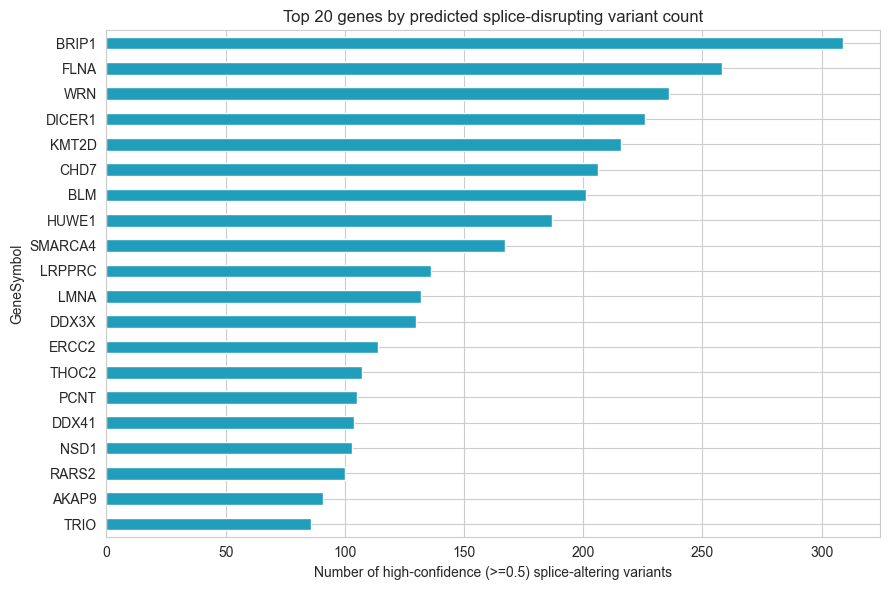

GeneSymbol
BRIP1      309
FLNA       258
WRN        236
DICER1     226
KMT2D      216
CHD7       206
BLM        201
HUWE1      187
SMARCA4    167
LRPPRC     136
LMNA       132
DDX3X      130
ERCC2      114
THOC2      107
PCNT       105
DDX41      104
NSD1       103
RARS2      100
AKAP9       91
TRIO        86
Name: count, dtype: int64

In [8]:
high_conf = df2[df2["max_score"] >= 0.5]
top_genes = high_conf["GeneSymbol"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(9, 6))
top_genes.sort_values().plot(kind="barh", ax=ax, color="#219ebc")
ax.set_xlabel("Number of high-confidence (>=0.5) splice-altering variants")
ax.set_title("Top 20 genes by predicted splice-disrupting variant count")
plt.tight_layout()
plt.show()

top_genes

## Delta position distribution

Where relative to the variant do predicted splicing changes occur? Restricting to high-confidence (>=0.5) hits -- do they cluster near the variant (canonical site disruption) or further away (cryptic site creation)?

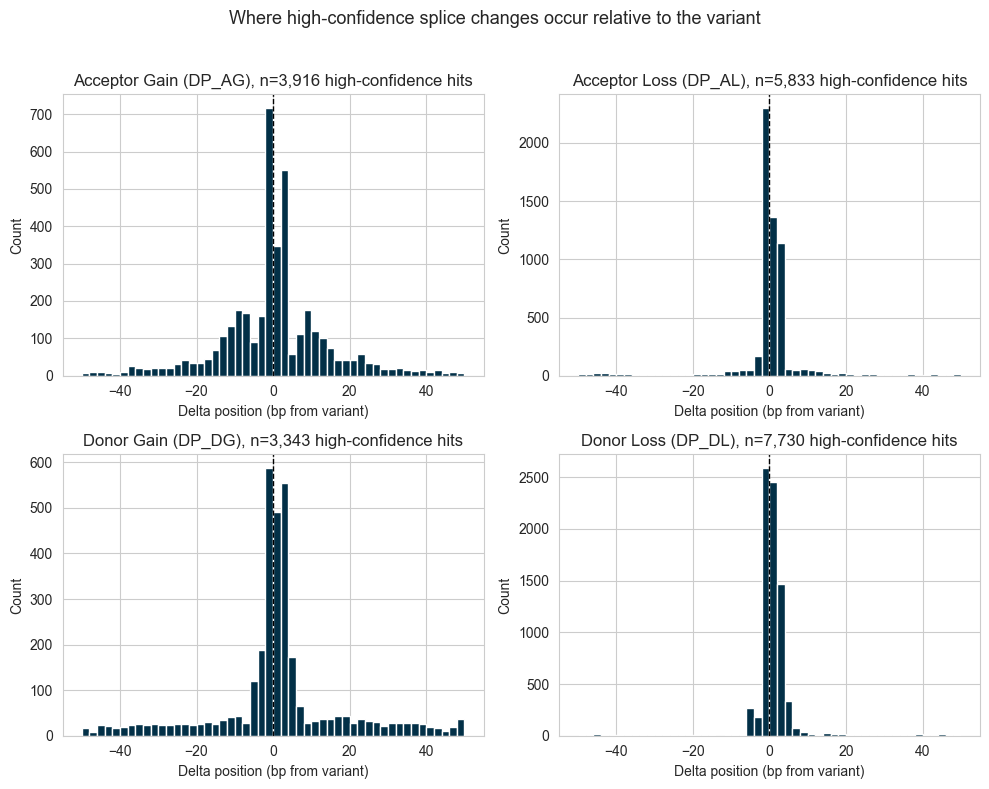

In [9]:
DP_COLS = ["DP_AG", "DP_AL", "DP_DG", "DP_DL"]
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, dp_col, score_col, label in zip(axes.flat, DP_COLS, SCORE_COLS, LABELS):
    subset = df2[df2[score_col] >= 0.5]
    ax.hist(subset[dp_col], bins=range(-50, 51, 2), color="#023047")
    ax.set_title(f"{label} ({dp_col}), n={len(subset):,} high-confidence hits")
    ax.set_xlabel("Delta position (bp from variant)")
    ax.set_ylabel("Count")
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
fig.suptitle("Where high-confidence splice changes occur relative to the variant", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()